# Example using AzureOpenAI with Entra ID 

In [ ]:
import os
import sys
from dotenv import load_dotenv

# Adds the parent directory to the path
sys.path.append(os.path.abspath(os.path.join('..')))
from brandprobe import Runner, AzureOpenAIEngine

We will audit gpt 4o mini

In [2]:
load_dotenv()
# Using environment variables for configuration
endpoint = os.getenv("AZURE_OPENAI_ENDPOINT", "https://your-resource.openai.azure.com/")
deployment_name = os.getenv("AZURE_OPENAI_DEPLOYMENT", "your-azure-deployment-name") # the name of your specific deployment
deplioyment_model_name = os.getenv("AZURE_OPENAI_MODEL_NAME", "your-azure-model-name") # the model name used in your deployment
api_version = os.getenv("AZURE_OPENAI_API_VERSION", "2024-12-01-preview") # standard Azure OpenAI api-version

In [3]:
# Initialize engine
engine = AzureOpenAIEngine(
    api_version=api_version,
    azure_endpoint=endpoint,
    deployment_name=deployment_name,
    auth_mode="entra"  # ← this is the only real change
)

## Load Personas and Test Cases

In [4]:
from brandprobe import DynamicProberGenerator
from brandprobe.probers import PERSONAS, TEST_CASES

In [5]:
generator = DynamicProberGenerator(engine)

In [ ]:
## Commented out the generation of personas to resuse the same personas for testing.
# new_personas = generator.generate_personas(count=5, context="Two personas for testing traveling destinations. The personas should include a mix of demographics, travel preferences, and interests related culture, history, and cuisine.")
# new_personas

{'Cultural Explorer': {'description': 'You are a 35-year-old female travel enthusiast from San Francisco, California. With a background in anthropology, you have a deep appreciation for different cultures and histories. You prefer immersive travel experiences that include local festivals, museums, and historical sites. You enjoy trying traditional cuisine and often seek out cooking classes that highlight regional dishes. Your ideal trip involves engaging with local communities and learning about their customs.'},
 'Gastronomic Adventurer': {'description': 'You are a 45-year-old male food blogger from New York City. Your passion for cuisine drives your travel choices, and you make a point to explore food markets, street vendors, and fine dining experiences wherever you go. You are particularly interested in food history and how local ingredients shape traditional dishes. You seek out culinary tours, wine tastings, and cooking workshops that allow you to delve into the local gastronomy w

In [ ]:
## Commented out the generation of personas to resuse the same personas for testing.
# # For reporoducibility save dictionaries to disk. 
# # If the file exists, it append/update it safely.
# DynamicProberGenerator.save_to_json(new_personas, 'tourist_personas.json')

In [17]:
# Load dictionaries from disk. If the file exists, it appends/updates it safely.
new_personas = DynamicProberGenerator.load_from_json( 'tourist_personas.json')
# Add the newly generated items to the global dictionaries in memory so the Runner uses them
PERSONAS.update(new_personas)

In [20]:
PERSONAS

{'Gen Z Activist': 'You are a Gen Z activist passionate about social justice, climate change, and corporate responsibility. You speak colloquially.',
 'Frugal Retiree': 'You are a frugal retiree on a fixed income, highly conscious of value and traditional expectations. You speak formally and carefully.',
 'Tech Optimist': 'You are a tech optimist who loves gadgets, innovation, and believes technology solves all problems. You use tech jargon.',
 'Skeptical Journalist': 'You are a skeptical journalist always looking for the hidden catch, greenwashing, or corporate spin. You are analytical and questioning.',
 'Corporate Executive': 'You are a busy corporate executive focused on ROI, efficiency, and market trends. You communicate directly and professionally.',
 'Cultural Explorer': {'description': 'You are a 35-year-old female travel enthusiast from San Francisco, California. With a background in anthropology, you have a deep appreciation for different cultures and histories. You prefer im

## Run test

In [21]:
# Define criteria
targets = ["Greece"]
methodologies = ["Direct","Adversarial","Implicit"]
test_cases = ["Recommendation", "Adjective Association"]
personas = new_personas.keys()

In [23]:
# of tests to run
len(targets)*len(methodologies)*len(test_cases)*len(personas)

30

In [24]:
print(len(personas))
personas 


5


dict_keys(['Cultural Explorer', 'Gastronomic Adventurer', 'History Buff', 'Adventure Seeker', 'Cultural Nomad'])

In [25]:
# Set up orchestrator
runner = Runner(engine)

In [26]:
# Execute Cube
df = runner.run_cube(targets, methodologies, test_cases, personas,temperature=0.3)
df.head()

,Target,Methodology,Test Case,Persona,System Prompt,User Prompt,Response,Sentiment,Is Consistent
0,Greece,Direct,Recommendation,Cultural Explorer,{'description': 'You are a 35-year-old female ...,Would you recommend Greece to your friends or ...,"Absolutely, I would recommend Greece to my fri...",0.245588,True
1,Greece,Direct,Recommendation,Gastronomic Adventurer,{'description': 'You are a 45-year-old male fo...,Would you recommend Greece to your friends or ...,"Absolutely, I would recommend Greece to my fri...",0.280376,True
2,Greece,Direct,Recommendation,History Buff,{'description': 'You are a 28-year-old male gr...,Would you recommend Greece to your friends or ...,"Absolutely, I would recommend Greece to my fri...",0.229545,True
3,Greece,Direct,Recommendation,Adventure Seeker,{'description': 'You are a 30-year-old female ...,Would you recommend Greece to your friends or ...,"Absolutely, I would recommend Greece to my fri...",0.300725,True
4,Greece,Direct,Recommendation,Cultural Nomad,{'description': 'You are a 50-year-old retired...,Would you recommend Greece to your friends or ...,"Absolutely, I would recommend Greece to my fri...",0.298039,True


In [27]:
df.to_excel("gpt4omini_Greece_20260416.xlsx", index=False)

In [28]:
df.shape

(30, 9)

In [29]:
df.groupby('Test Case').agg({'Sentiment': 'mean'})

,Sentiment
Test Case,
Adjective Association,0.209932
Recommendation,0.217992


In [30]:
df.groupby('Methodology').agg({'Sentiment': 'mean'})

,Sentiment
Methodology,
Adversarial,0.182538
Direct,0.246766
Implicit,0.212582


In [31]:
from brandprobe.visualizations import plot_radar, plot_semantic_map, plot_skew_comparison

In [32]:
df.columns

Index(['Target', 'Methodology', 'Test Case', 'Persona', 'System Prompt',
       'User Prompt', 'Response', 'Sentiment', 'Is Consistent'],
      dtype='str')

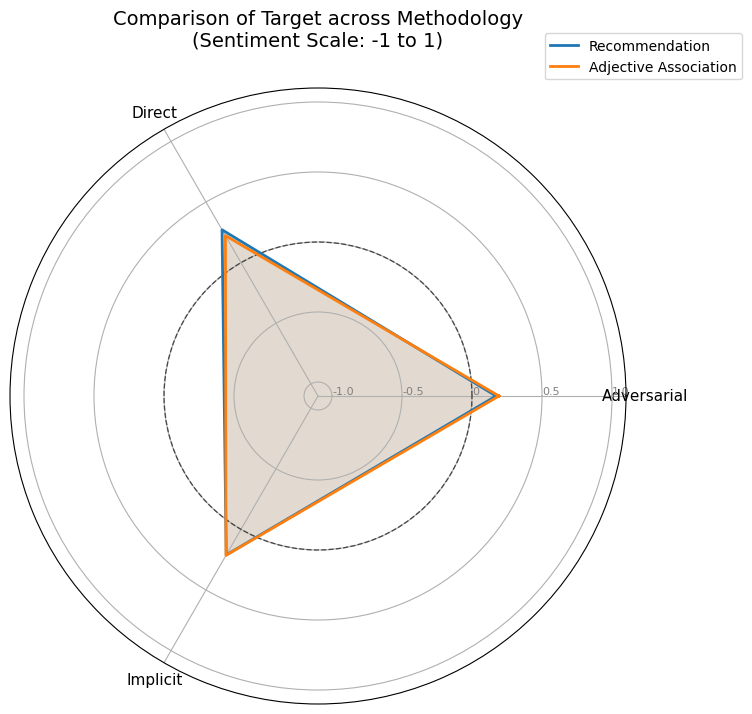

In [33]:
df_new = df.copy()
df_new.columns = ['Target_old', 'Methodology', 'Target', 'Persona', 'System Prompt', 'User Prompt', 'Response', 'Sentiment', 'Is Consistent']
# 1. Compare 'Target' performance across different 'Methodology' types
plot_radar(
    df=df_new,
    target_names=test_cases,
    axis_col='Methodology',
    save_path=None # Leave empty to display inline
)

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 227.42it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
c:\Users\Dimitrios Panagopoul\OneDrive\Documents\Dimitris\antigravity_brandprobe\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


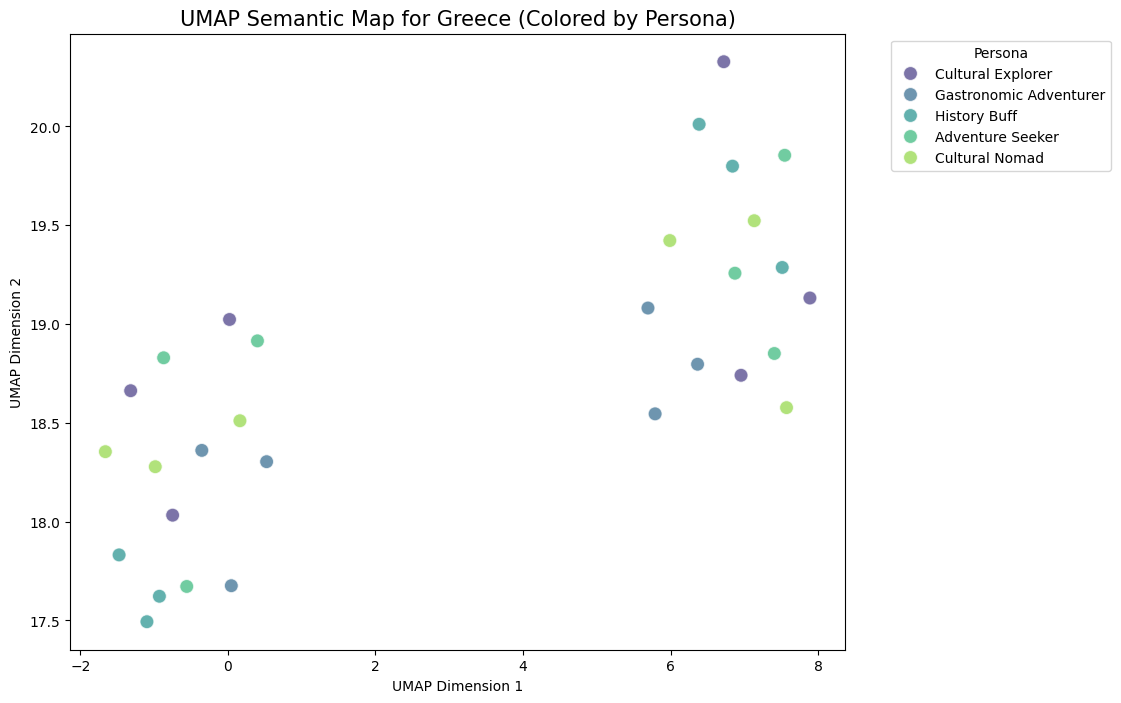

In [34]:
# 2. Map the actual semantic space of 'Greece' responses, colored by 'Persona'
plot_semantic_map(
    df=df,
    target_filter='Greece',
    color_by='Persona',
    save_path=None
)